<img src=".\assets\on_black.png" alt="netective logo" style="width:18%;">

Compare networks based on their structure and performance statistics.
<br><br>
## Python Module Tutorial

Explore the main features of the Python module for network comparison.

- For a tutorial on the command-line interface, refer to [this link]().
- Access the web service for small jobs [here]().

---

The module consists of two submodules: `structure` and `stats`, each with module-level functions for convenient usage.

In this guide, we'll cover the following topics:

1. **Module-level functions** 📦
2. **Submodule `structure`** 🕸️📐
   Useful for comparing networks with different node IDs.

3. **Submodule `stats`** 📊
   Requires networks to share node IDs. Useful for comparing inferred networks against a gold standard.

<br>

Make sure to have netective installed:

In [3]:
# %pip install netective

<br>

### Module-level functions 📦

The module-level functions empower users, even those with basic Python proficiency, to seamlessly employ netective to characterize network structure, compare networks, and assess inference performance.

In [4]:
# Third-party imports
import networkx as nx

from scipy.stats import spearmanr

#### characterize network structure

Properties used for analysis:  Average Clustering Coefficient Average Degree for Nearest Neighbors (Undirected) Average Local Efficiency Average Degree for Nearest Neighbors (Out-Out) Average Shortest Path Length Betweenness Centrality Center Clustering Coefficient Complex Feed-Forward Circuits Density Diameter Eccentricity Entropy of Degree Distribution 3-Feedback Loops Gene % in the Giant Component Gini Index Global Efficiency In-Degree Locality Index Max In-Dregree Max Out-Degree Out-Degree Periphery Radius Regulators Rich Club Coefficient Self-Regulations Subgraph Centrality 



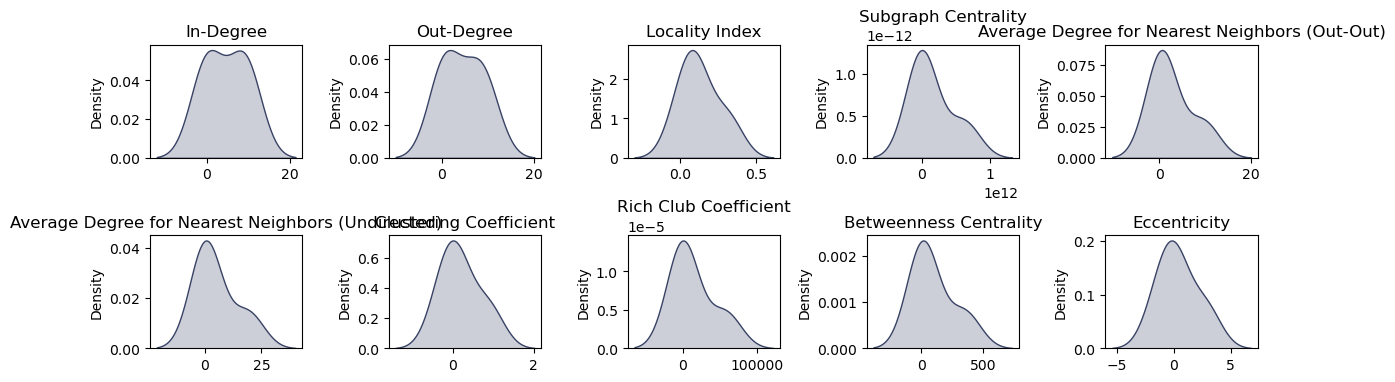

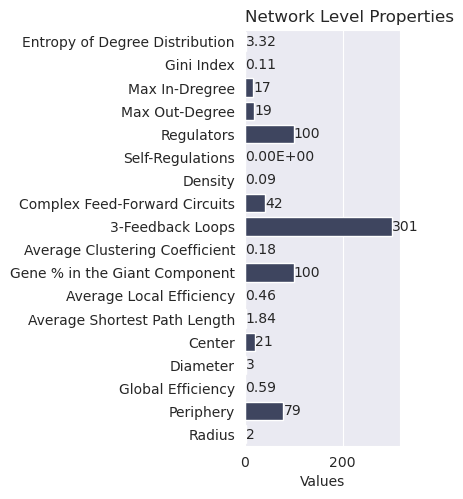

In [5]:
from netective import characterize_network

# Let's create a random network to characterize
G = nx.erdos_renyi_graph(100, 0.1, directed=True)

# Characterize the network is as simple as calling the function with the network and an identifier as arguments
characterize_network(G, "my_network")

Networks may have different size. Use the norm parameter to get normalized values.

Properties used for analysis:  Average Clustering Coefficient Average Degree for Nearest Neighbors (Undirected) Average Local Efficiency Average Degree for Nearest Neighbors (Out-Out) Average Shortest Path Length Betweenness Centrality Center Clustering Coefficient Complex Feed-Forward Circuits Density Diameter Eccentricity Entropy of Degree Distribution 3-Feedback Loops Gene % in the Giant Component Gini Index Global Efficiency In-Degree Locality Index Max In-Dregree Max Out-Degree Out-Degree Periphery Radius Regulators Rich Club Coefficient Self-Regulations Subgraph Centrality 



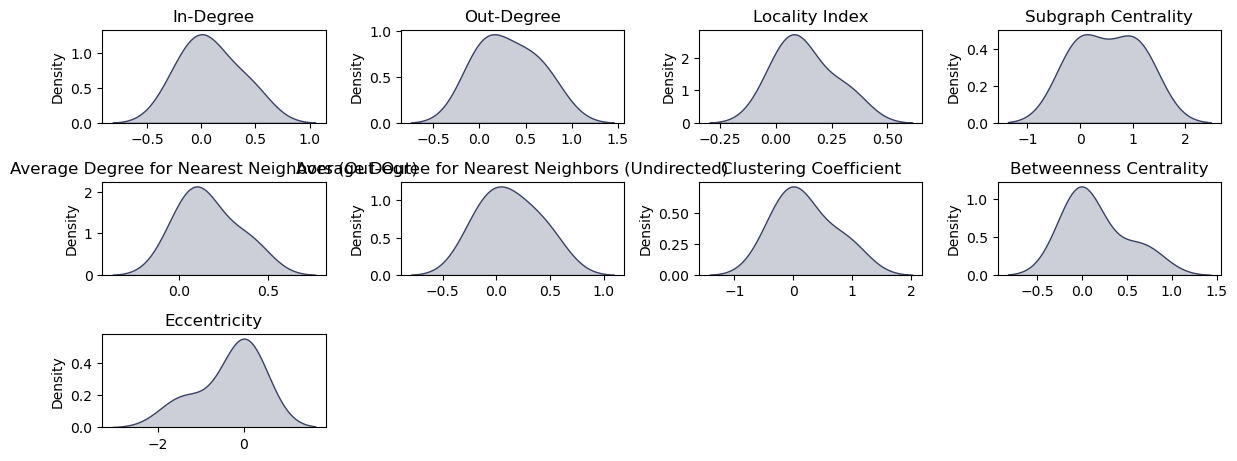

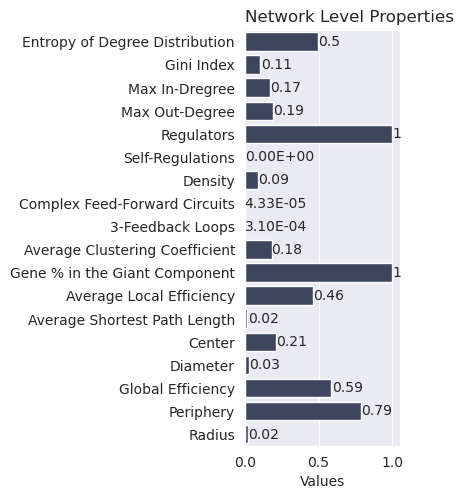

In [6]:
# norm parameter allows you to normalize data using different approaches depending on the nature of the networks analyzed
# default is None for no normalization, uses raw data
# norm = "network" normalize the network by the network size, its default value is None

characterize_network(G, "my_network", norm="network")

Netective v1.0 uses a total of 28 network properties for characterization and comparison:

`Node-Level Properties`
- In-Degree (InDegre)
- Out-Degree (OutDegre)
- Locality Index (LocalityIndex)
- Subgraph Centrality (SubgraphCentrality)
- Average Degree of Nearest Neighbors using out-out degree (AverageOutDegreeNearestNeighbors)
- Average Degree of Nearest Neighbors using undirected network (AverageDegreeNearestNeighbors)
- Clustering Coefficient (ClusteringCoefficient)
- Rich Club Coefficient (RichClub)
- Betweenness Centrality (BetweennessCentrality)
- Eccentricity (Eccentricity)

`Network-Level Properties`
- Entropy of Degree Distribution (EntropyPKout)
- Gini Index (GiniIndex)
- Max In-Degree (MaxInDegree)
- Max Out-Degree (MaxOutDegree)
- Regulators (Regulators)
- Self-Regulations (SelfRegulations)
- Density (Density)
- Complex Feed-Forward Circuits (ComplexFeedForwardCircuits)
- 3-Feedback Loops (FeedbakcLoops_3)
- Average Clustering Coefficient (AverageClusteringCoefficient)
- Gene % in the Giant Component (GenesintheGiantComponent)
- Average Local Efficiency (AverageLocalEfficiency)
- Average Shortest Path Length (AverageShortestPathLength)
- Center (Center)
- Diameter (Diameter)
- Global Efficiency (GlobalEfficiency)
- Periphery (Periphery)
- Radius (Radius)

***correct spelling for list in parenthesis***

characterize_network function allows you to provide a list of chosen properties to use if you do not want to use the complete set, using the parameter selected_props ***default is all properties***

Properties used for analysis:  Density Diameter GiniIndex InDegree LocalityIndex 



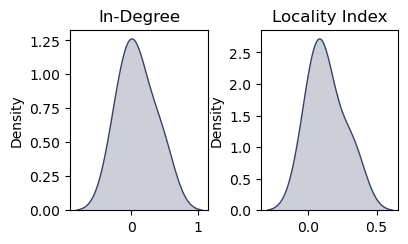

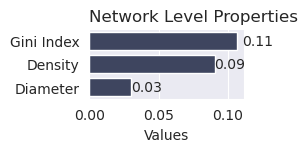

In [15]:
# using the same network

my_properties = ['GiniIndex', 'Density', 'Diameter', 'LocalityIndex', 'InDegree']

characterize_network(G, "my_network", norm="network", selected_props= my_properties)

#### compare networks based on their structure

Properties used for analysis:  Average Clustering Coefficient Average Degree for Nearest Neighbors (Undirected) Average Local Efficiency Average Degree for Nearest Neighbors (Out-Out) Average Shortest Path Length Betweenness Centrality Center Clustering Coefficient Complex Feed-Forward Circuits Density Diameter Eccentricity Entropy of Degree Distribution 3-Feedback Loops Gene % in the Giant Component Gini Index Global Efficiency In-Degree Locality Index Max In-Dregree Max Out-Degree Out-Degree Periphery Radius Regulators Rich Club Coefficient Self-Regulations Subgraph Centrality 



  0%|          | 0/7 [00:00<?, ?it/s]

Running my_network_G
Running my_network_H


 29%|██▊       | 2/7 [00:07<00:18,  3.72s/it]


(<Figure size 1000x1000 with 4 Axes>, <Figure size 1000x1000 with 4 Axes>)

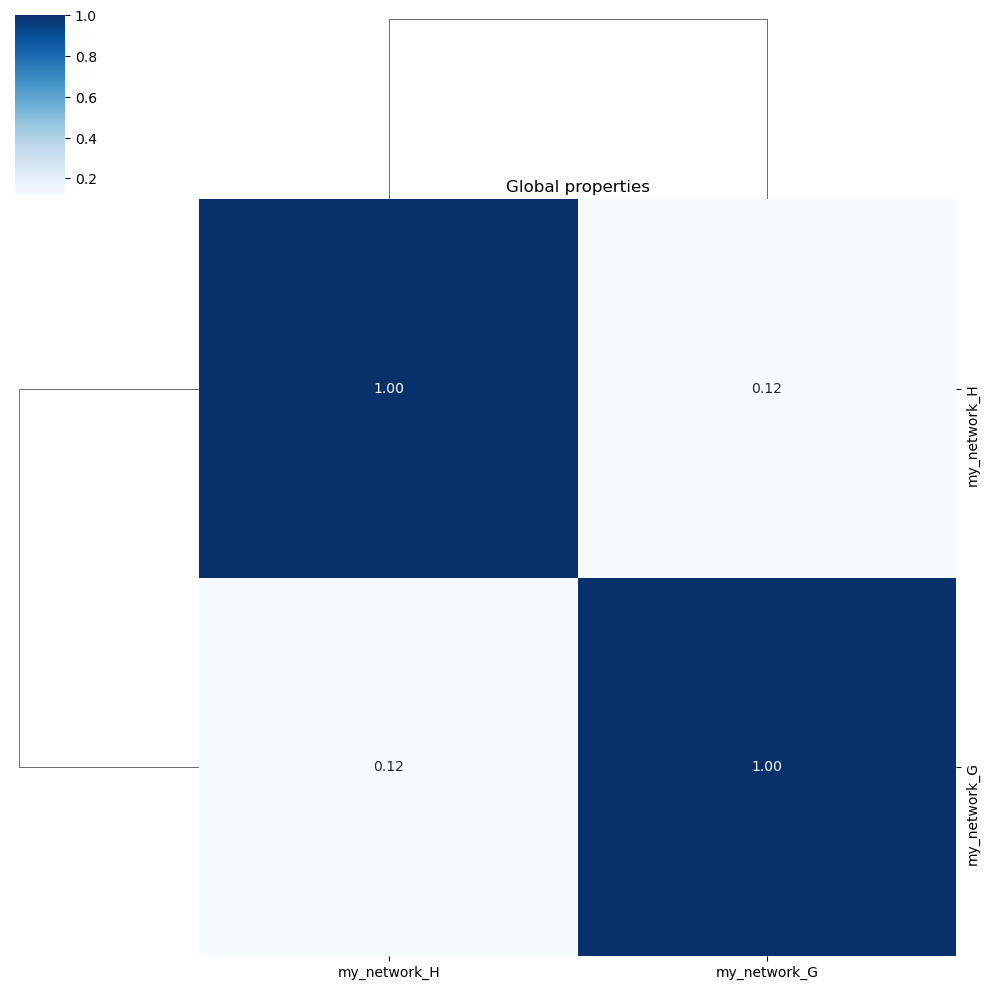

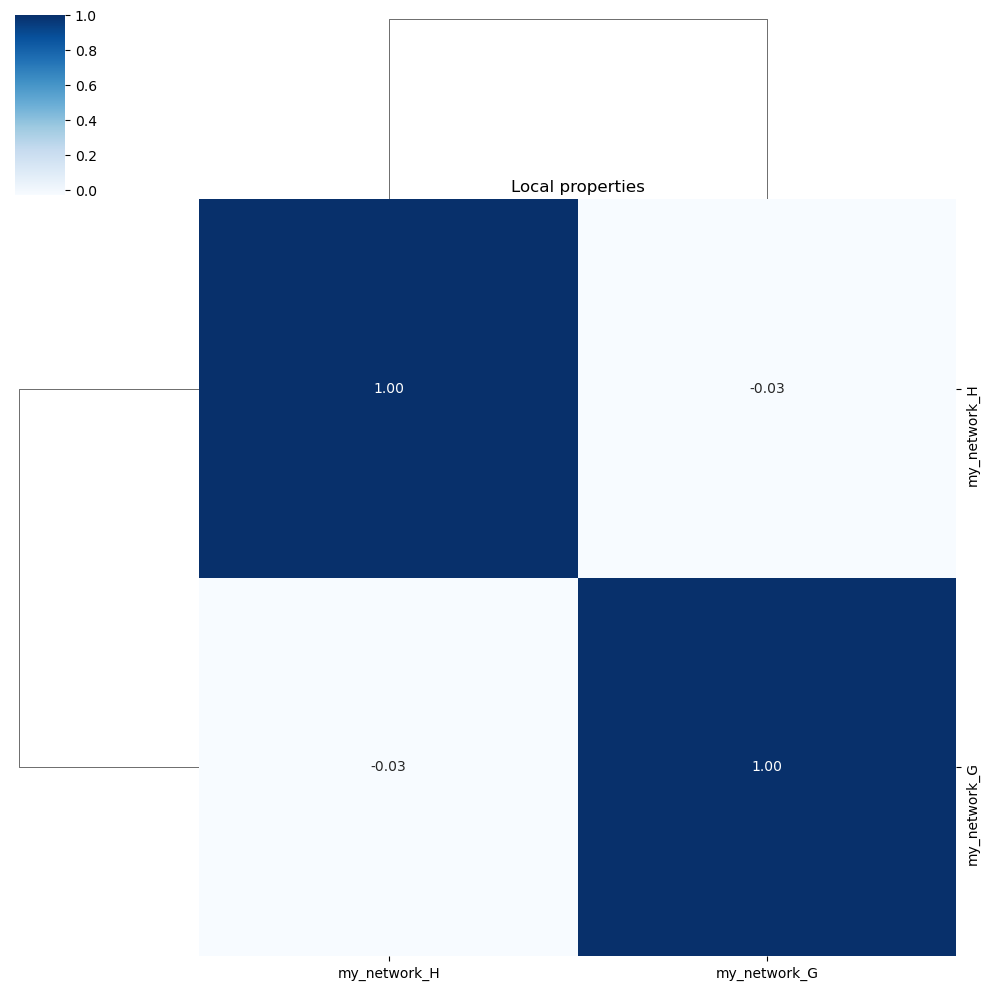

In [8]:
from netective import compare_structure

# Let's create a second network to compare to the first one.
H = nx.path_graph(50, create_using=nx.DiGraph)

# Comparing both networks is as simple as calling the function with a dictionary of networks.
networks = {"my_network_G": G, "my_network_H": H}
compare_structure(networks)

Properties used for analysis:  Average Clustering Coefficient Average Degree for Nearest Neighbors (Undirected) Average Local Efficiency Average Degree for Nearest Neighbors (Out-Out) Average Shortest Path Length Betweenness Centrality Center Clustering Coefficient Complex Feed-Forward Circuits Density Diameter Eccentricity Entropy of Degree Distribution 3-Feedback Loops Gene % in the Giant Component Gini Index Global Efficiency In-Degree Locality Index Max In-Dregree Max Out-Degree Out-Degree Periphery Radius Regulators Rich Club Coefficient Self-Regulations Subgraph Centrality 



  0%|          | 0/7 [00:00<?, ?it/s]

Running my_network_G
Running my_network_H


 29%|██▊       | 2/7 [00:05<00:12,  2.57s/it]


(<Figure size 1000x1000 with 4 Axes>, <Figure size 1000x1000 with 4 Axes>)

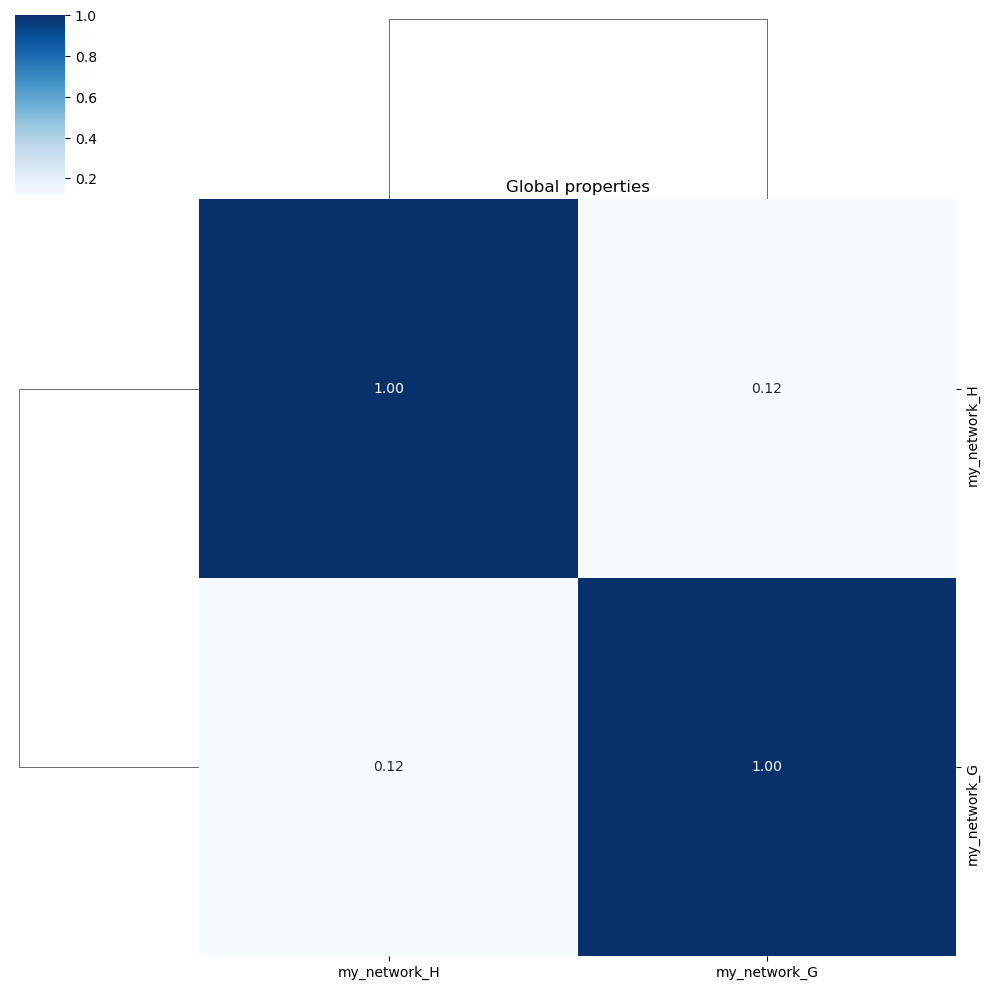

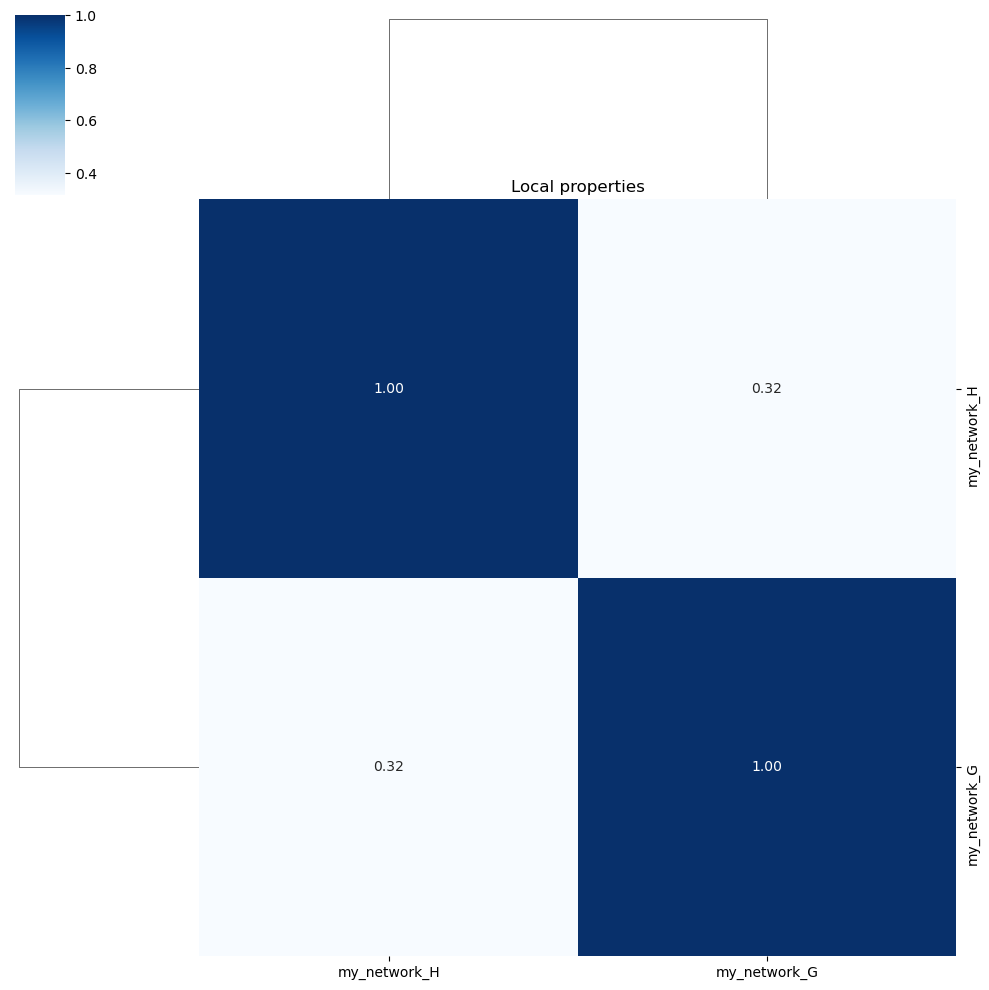

In [9]:
# pearsonr is used by default to compare networks. Other methods are available using the parameter association_metric.
# compare_networks runs in parallel by default. Use workers to specify the number of processes to run in parallel.

compare_structure(networks, workers=2, association_metric=spearmanr)

Properties used for analysis:  ClusteringCoefficient Density EntropyPKout OutDegree Regulators 



  0%|          | 0/7 [00:00<?, ?it/s]

Running my_network_G
Running my_network_H


 29%|██▊       | 2/7 [00:08<00:20,  4.14s/it]


(<Figure size 1000x1000 with 4 Axes>, <Figure size 1000x1000 with 4 Axes>)

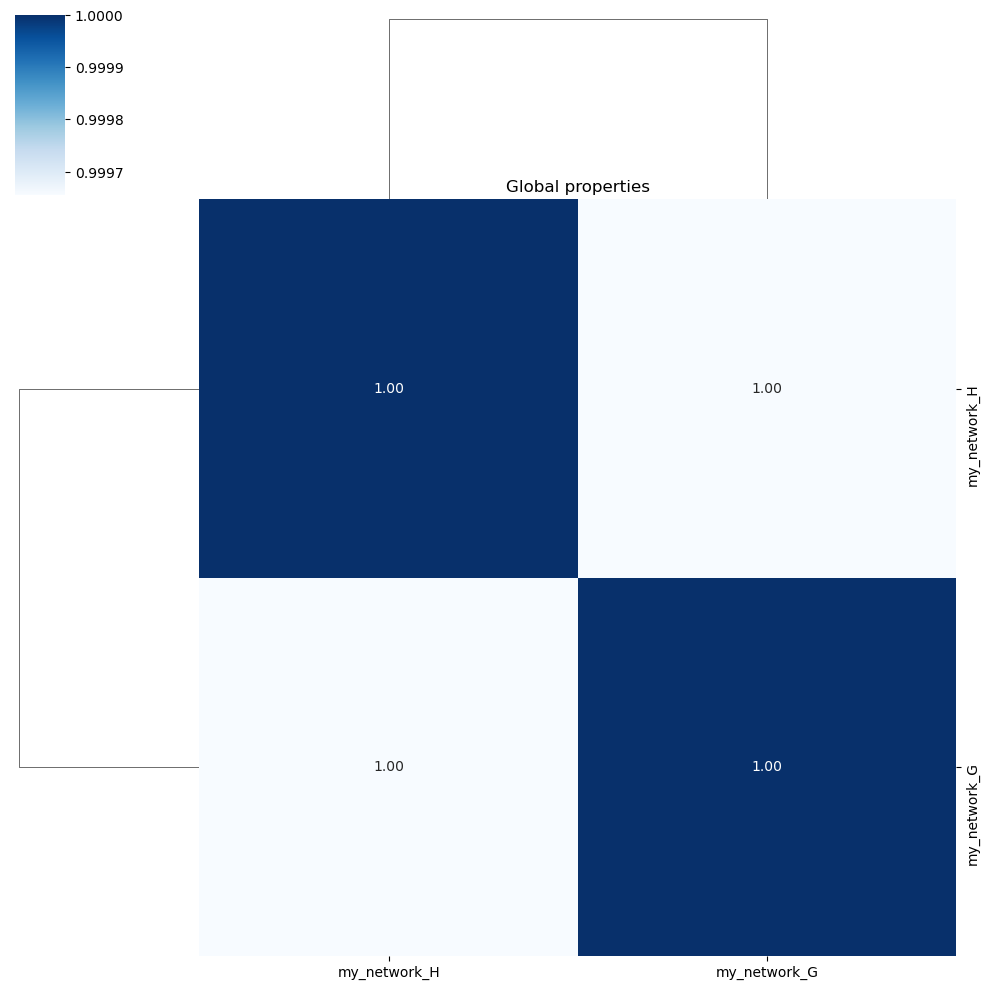

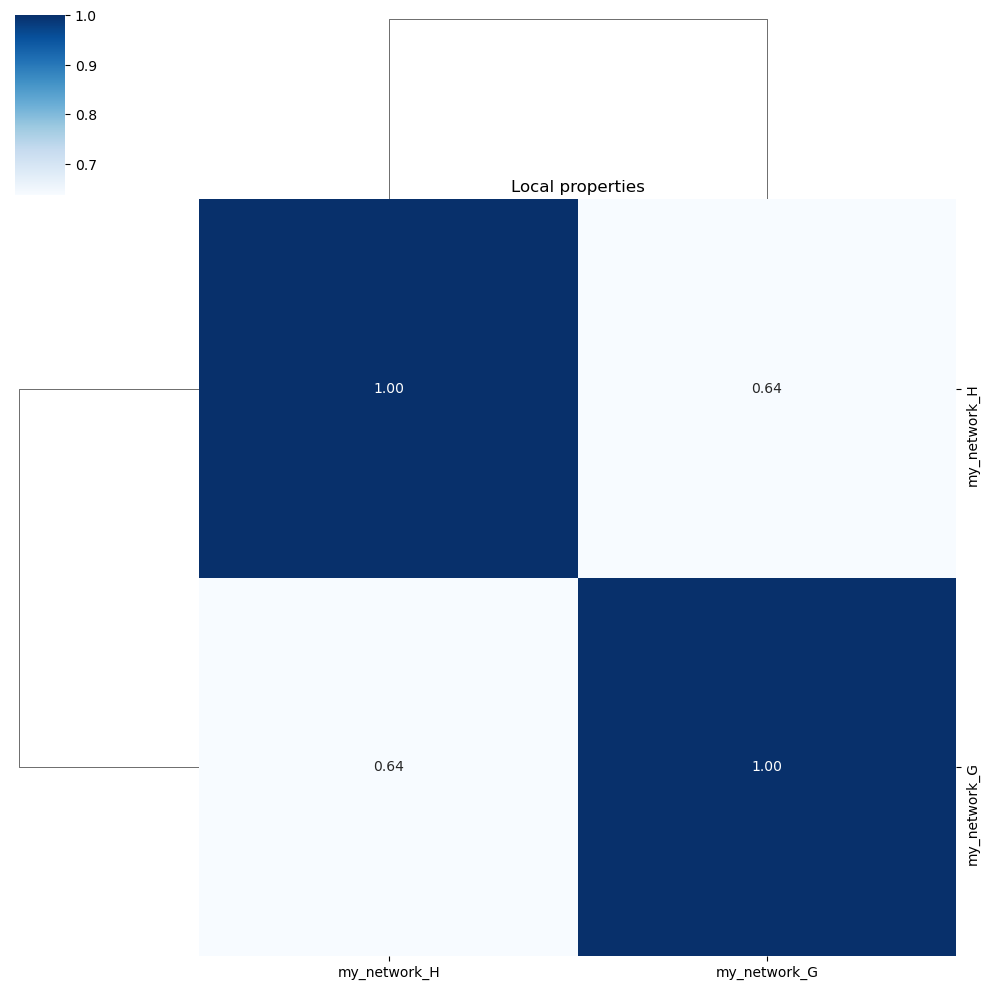

In [17]:
# just like characterize_network, compare_structure function allows you to provide the list of chosen properties for analysis using the parameter selected_props

my_properties = ['EntropyPKout', 'ClusteringCoefficient', 'OutDegree', 'Density', 'Regulators']
compare_structure(networks, workers=2, association_metric=spearmanr, selected_props= my_properties)